In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from statsmodels.othermod.betareg import BetaModel
from sklearn.linear_model import LassoLarsIC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


column_names = []

with open("communities.names") as f:
    for line in f:
        if line.startswith("@attribute"):
            column_names.append(line.split(" ")[1])

# Load data with headers
df = pd.read_csv("communities.data",
                 names=column_names,
                 na_values="?")

df = df.apply(pd.to_numeric, errors="coerce")

#Drop Non-predictive columns
df = df.drop(columns=["state", "county", "community", "communityname", "fold"], errors="ignore")
df = df[df['pctUrban'] > 0.75]



In [2]:
economic_vars = [
'PctPopUnderPov',
'perCapInc',
'medIncome',
'PctUnemployed',
'PctNotHSGrad',
'PctBSorMore',
'pctWSocSec',
'pctWInvInc',
'MedRentPctHousInc',
'PctOccupMgmtProf'
]

structural_vars = [
'PopDens',
'PctUsePubTrans',
'PctPersDenseHous',
'PctVacantBoarded',
'HousVacant',
'PctHousNoPhone',
'PctHousLess3BR',
'PctHousOwnOcc',
'NumInShelters',
'LandArea'
]

demographic_vars = [
'PctKids2Par',
'PctIlleg',
'racePctWhite',
'racepctblack',
'FemalePctDiv',
'TotalPctDiv',
'agePct12t29',
'population',
'PctLargHouseFam',
'PctSpeakEnglOnly'
]

target = ['ViolentCrimesPerPop']
features = economic_vars + structural_vars + demographic_vars
#df = df[features + target]

#subset = df[vars_of_interest]
econ = df[economic_vars]
struct = df[structural_vars]
demo = df[demographic_vars]
totalSample = df[features]

#clean dataset
clean_df = df.dropna()

#dirty dataset
dirty_df = df.fillna(df.median())


In [83]:
st_total = pd.DataFrame({
    "Mean": totalSample.mean(),
    "Median": totalSample.median(),
    "Std Dev": totalSample.std(),
    "Min": totalSample.min(),
    "Max": totalSample.max()
})

st_total = st_total.round(2)

st_total

,Mean,Median,Std Dev,Min,Max
PctPopUnderPov,0.26,0.19,0.21,0.00,1.00
perCapInc,0.39,0.35,0.20,0.01,1.00
medIncome,0.41,0.37,0.21,0.00,1.00
PctUnemployed,0.33,0.29,0.19,0.00,1.00
PctNotHSGrad,0.35,0.32,0.20,0.00,1.00
PctBSorMore,0.39,0.34,0.22,0.00,1.00
pctWSocSec,0.45,0.45,0.17,0.05,1.00
pctWInvInc,0.52,0.51,0.18,0.00,1.00
MedRentPctHousInc,0.49,0.49,0.17,0.00,1.00
PctOccupMgmtProf,0.47,0.44,0.20,0.00,1.00


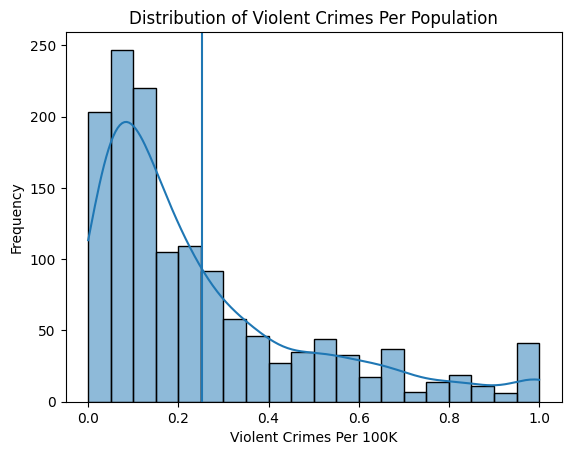

In [ ]:


plt.figure()
sns.histplot(df["ViolentCrimesPerPop"], kde=True)
plt.axvline(df["ViolentCrimesPerPop"].mean())
plt.title("Distribution of Violent Crimes Per Population")
plt.xlabel("Violent Crimes Per 100K")
plt.ylabel("Population")
plt.show()

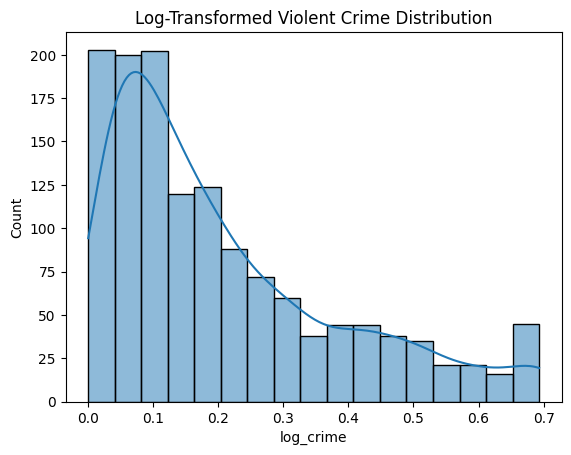

In [85]:
df["log_crime"] = np.log1p(df["ViolentCrimesPerPop"])

plt.figure()
sns.histplot(df["log_crime"], kde=True)
plt.title("Log-Transformed Violent Crime Distribution")
plt.show()

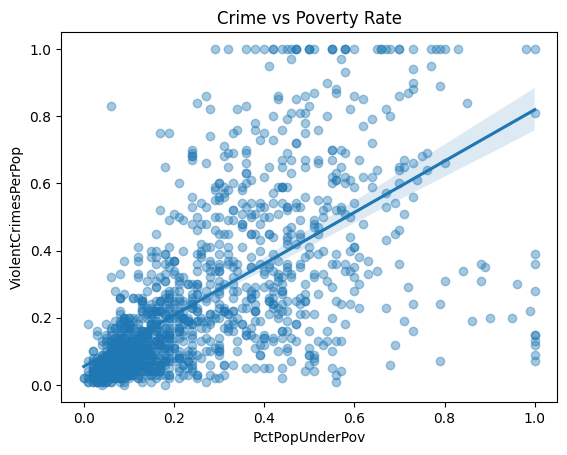

In [86]:
plt.figure()
sns.regplot(x="PctPopUnderPov",
            y="ViolentCrimesPerPop",
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Crime vs Poverty Rate")
plt.show()

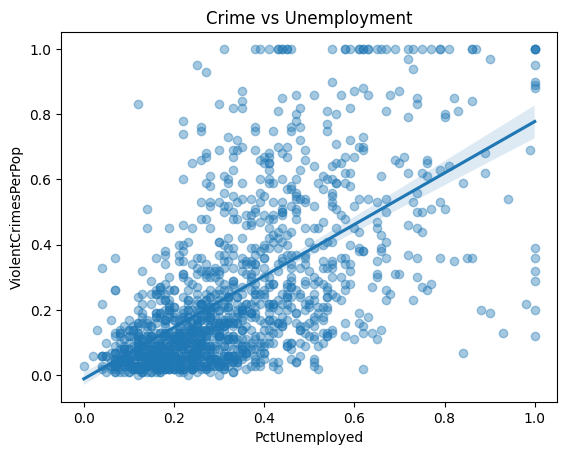

In [87]:
plt.figure()
sns.regplot(x="PctUnemployed",
            y="ViolentCrimesPerPop",
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Crime vs Unemployment")
plt.show()

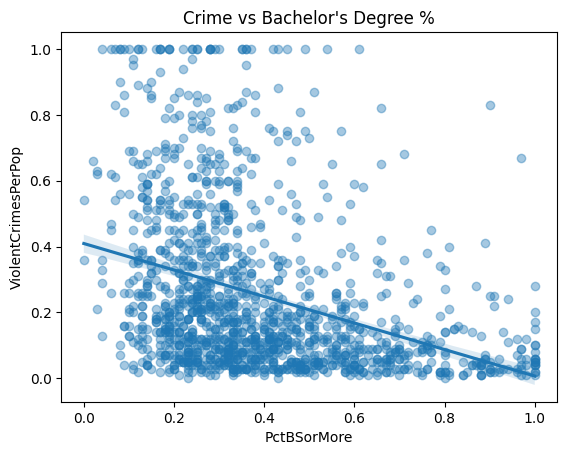

In [88]:
plt.figure()
sns.regplot(x="PctBSorMore",
            y="ViolentCrimesPerPop",
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Crime vs Bachelor's Degree %")
plt.show()

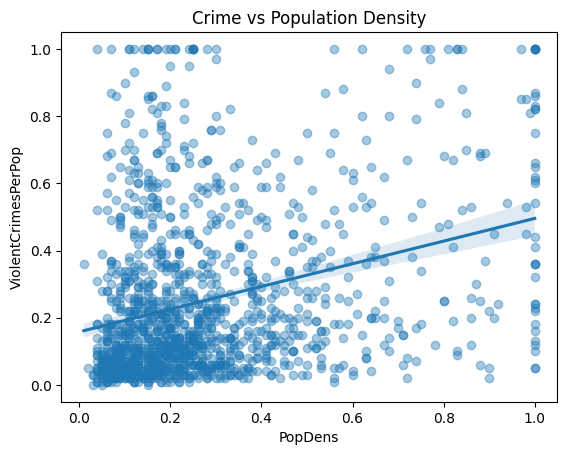

In [89]:
plt.figure()
sns.regplot(x="PopDens",
            y="ViolentCrimesPerPop",
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Crime vs Population Density")
plt.show()

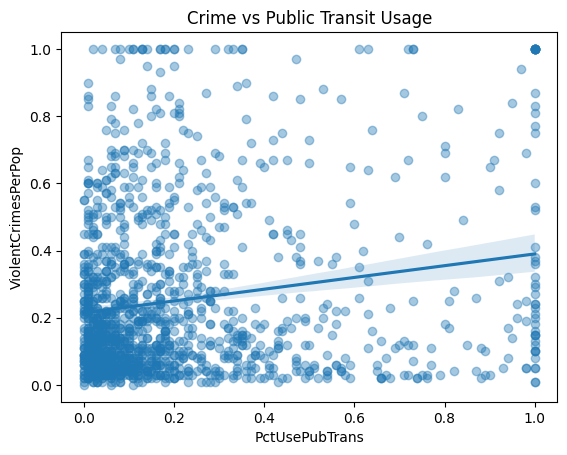

In [90]:
plt.figure()
sns.regplot(x="PctUsePubTrans",
            y="ViolentCrimesPerPop",
            data=df,
            scatter_kws={'alpha':0.4})
plt.title("Crime vs Public Transit Usage")
plt.show()

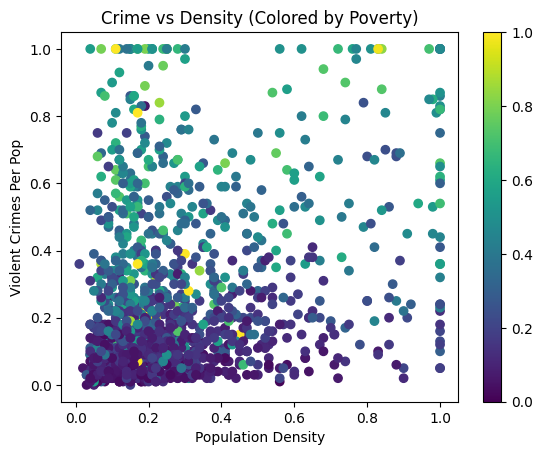

In [91]:
plt.figure()
scatter = plt.scatter(df["PopDens"],
                      df["ViolentCrimesPerPop"],
                      c=df["PctPopUnderPov"])

plt.colorbar(scatter)
plt.xlabel("Population Density")
plt.ylabel("Violent Crimes Per Pop")
plt.title("Crime vs Density (Colored by Poverty)")
plt.show()

In [92]:
urban_df = df[df["pctUrban"] > 0.75]

print("Original dataset size:", df.shape)
print("Urban dataset size:", urban_df.shape)

# Compare crime rates
df["UrbanCommunity"] = (df["pctUrban"] > 0.75).astype(int)

crime_compare = df.groupby("UrbanCommunity")["ViolentCrimesPerPop"].mean()

print("\nAverage Crime Rates:")
print(crime_compare)

Original dataset size: (1371, 124)
Urban dataset size: (1371, 124)

Average Crime Rates:
UrbanCommunity
1    0.252254
Name: ViolentCrimesPerPop, dtype: float64


In [93]:
#Linear Regression with clean data
#Train-Test aplit
X = clean_df[features]
y = clean_df['ViolentCrimesPerPop']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#linear Regression model
linreg = LinearRegression()

linreg.fit(X_train, y_train)

#Predictions
y_pred = linreg.predict(X_test)

#MSE
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

threshold = 0.1

y_test_binary = (y_test > threshold).astype(int)
y_pred_binary = (y_pred > threshold).astype(int)

accuracy = accuracy_score(y_test_binary, y_pred_binary)

print("Accuracy:", accuracy)

#10-Fold Cross Validation
cv_scores = cross_val_score(
    linreg,
    X,
    y,
    cv=10,
    scoring='neg_mean_squared_error'
)

cv_mse = -cv_scores.mean()

print("10-Fold CV MSE:", cv_mse)

lin_coefs = pd.Series(linreg.coef_, index=features)

top5_linear = lin_coefs.abs().sort_values(ascending=False).head(5)

print("Top 5 Linear Regression Features:")
print(top5_linear.to_string())

Mean Squared Error: 0.033242613522543873
Accuracy: 0.921875
10-Fold CV MSE: 0.029505581394302965
Top 5 Linear Regression Features:
pctWInvInc       1.160741
PctNotHSGrad     0.661413
PctBSorMore      0.580195
PctKids2Par      0.536938
PctHousOwnOcc    0.353574


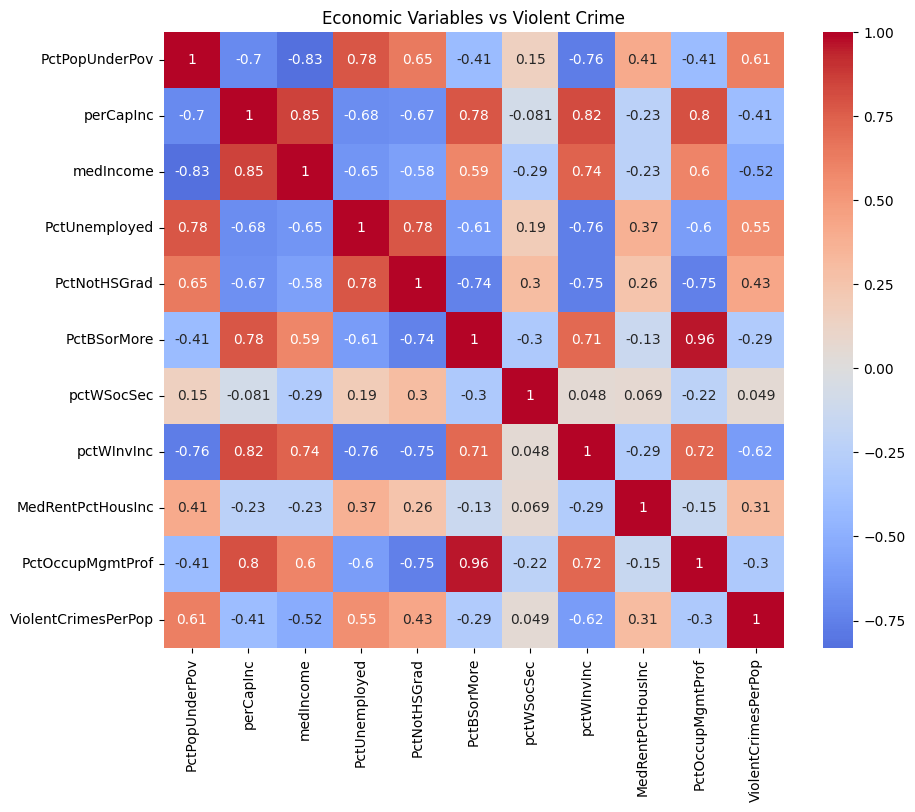

In [94]:
econ_corr = clean_df[economic_vars + target].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    econ_corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Economic Variables vs Violent Crime")
plt.show()

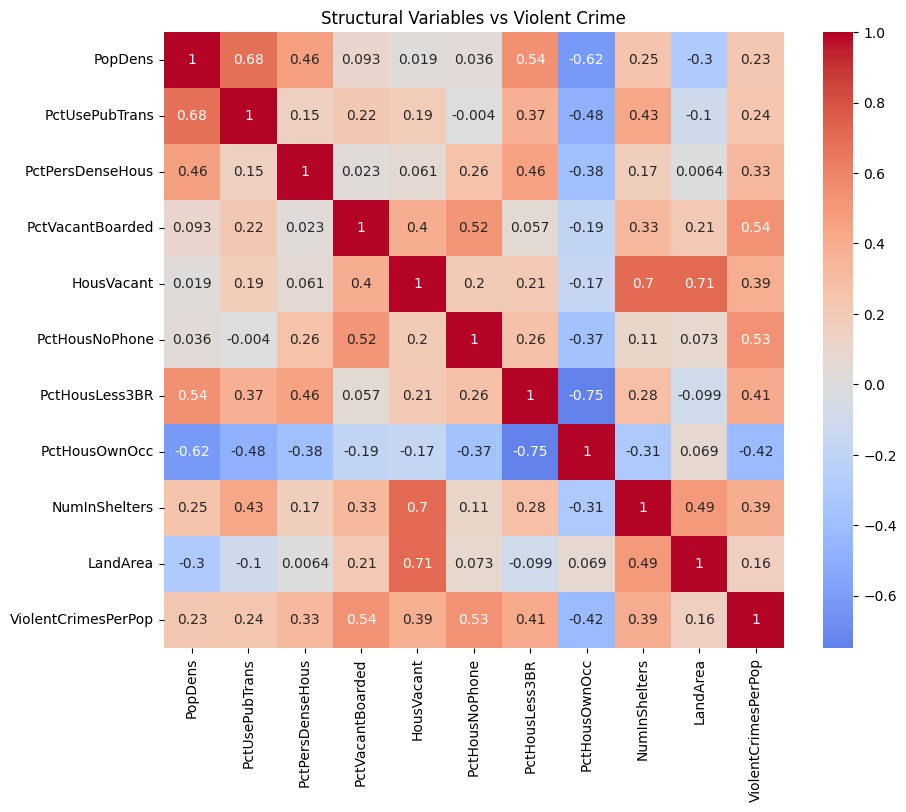

In [95]:
struct_corr = clean_df[structural_vars + target].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    struct_corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Structural Variables vs Violent Crime")
plt.show()

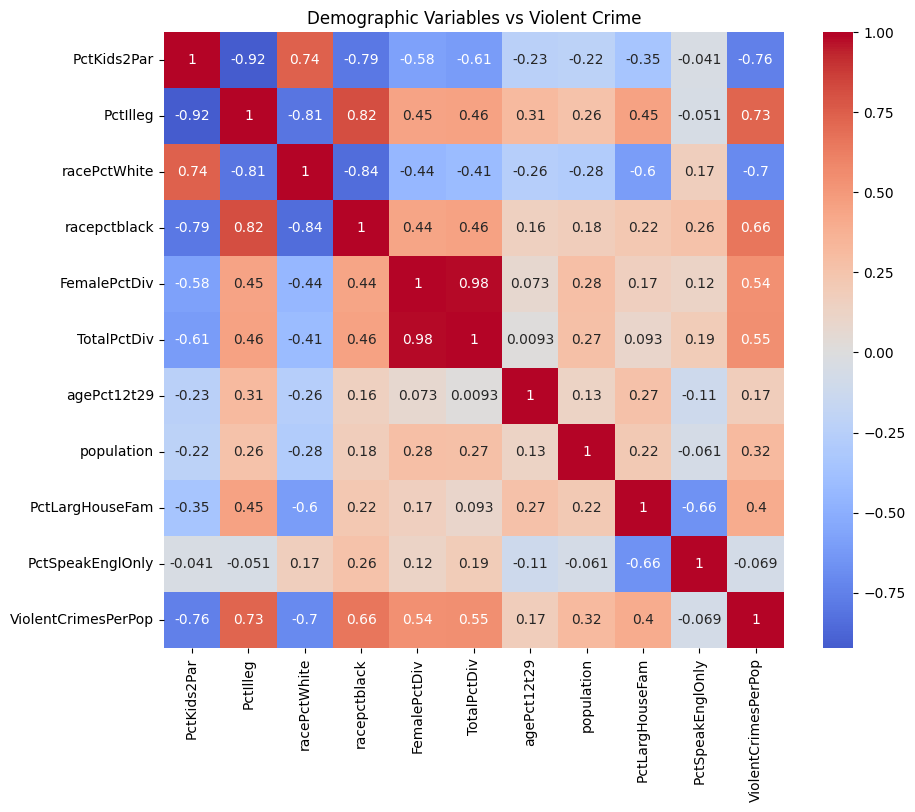

In [96]:
demo_corr = clean_df[demographic_vars + target].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    demo_corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Demographic Variables vs Violent Crime")
plt.show()

In [97]:
#Decision Tree classifyer with clean data:
# Create High Crime variable
threshold = 0.1

clean_df['HighCrime'] = (clean_df['ViolentCrimesPerPop'] > threshold).astype(int)
dirty_df['HighCrime'] = (dirty_df['ViolentCrimesPerPop'] > threshold).astype(int)

#Training:
X = clean_df[features]
y = clean_df['HighCrime']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#DT model
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)

#10-fold cross validation
dt_cv_accuracy = cross_val_score(
    dt_model,
    X,
    y,
    cv=10,
    scoring='accuracy'
)

print("Decision Tree 10-Fold CV Accuracy:", dt_cv_accuracy.mean())

dt_importance = pd.Series(
    dt_model.feature_importances_,
    index=features
)

top5_dt = dt_importance.sort_values(ascending=False).head(5)

print("Top 5 Decision Tree Features:")
print(top5_dt)

Decision Tree Performance
Accuracy: 0.875
Precision: 0.9649122807017544
Recall: 0.9016393442622951
F1 Score: 0.9322033898305084
Decision Tree 10-Fold CV Accuracy: 0.9088709677419355
Top 5 Decision Tree Features:
pctWInvInc        0.349741
racePctWhite      0.149196
PctPopUnderPov    0.094875
HousVacant        0.084551
PctHousOwnOcc     0.082492
dtype: float64


/var/folders/gq/vx40gmgs7r3ctcswx6p9jk200000gn/T/ipykernel_1076/1179322710.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dirty_df['HighCrime'] = (dirty_df['ViolentCrimesPerPop'] > threshold).astype(int)


Random Forest Performance
Accuracy: 0.96875
Precision: 0.9836065573770492
Recall: 0.9836065573770492
F1 Score: 0.9836065573770492
Random Forest 10-Fold CV Accuracy: 0.9213709677419356
PctPopUnderPov      0.135249
PctPersDenseHous    0.073070
pctWInvInc          0.069935
racePctWhite        0.059720
PctIlleg            0.052077
PctKids2Par         0.051581
HousVacant          0.043144
PctHousNoPhone      0.040011
racepctblack        0.037560
PctLargHouseFam     0.033972
TotalPctDiv         0.029784
PctSpeakEnglOnly    0.026253
medIncome           0.025961
PctNotHSGrad        0.025881
PctHousLess3BR      0.025468
dtype: float64


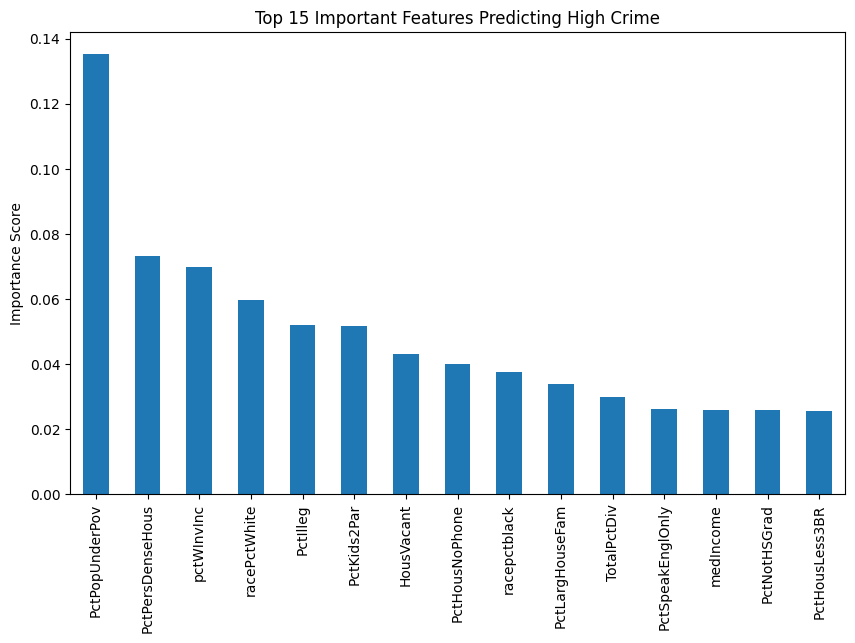

Top 5 Random Forest Features:
PctPopUnderPov      0.135249
PctPersDenseHous    0.073070
pctWInvInc          0.069935
racePctWhite        0.059720
PctIlleg            0.052077
dtype: float64


In [98]:
#Random Forest Classifies with clean data
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)

rf_cv_accuracy = cross_val_score(
    rf_model,
    X,
    y,
    cv=10,
    scoring='accuracy'
)

print("Random Forest 10-Fold CV Accuracy:", rf_cv_accuracy.mean())

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance.head(15))

plt.figure(figsize=(10,6))

feature_importance.head(15).plot(kind='bar')

plt.title("Top 15 Important Features Predicting High Crime")
plt.ylabel("Importance Score")

plt.show()

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
)

top5_rf = rf_importance.sort_values(ascending=False).head(5)

print("Top 5 Random Forest Features:")
print(top5_rf)

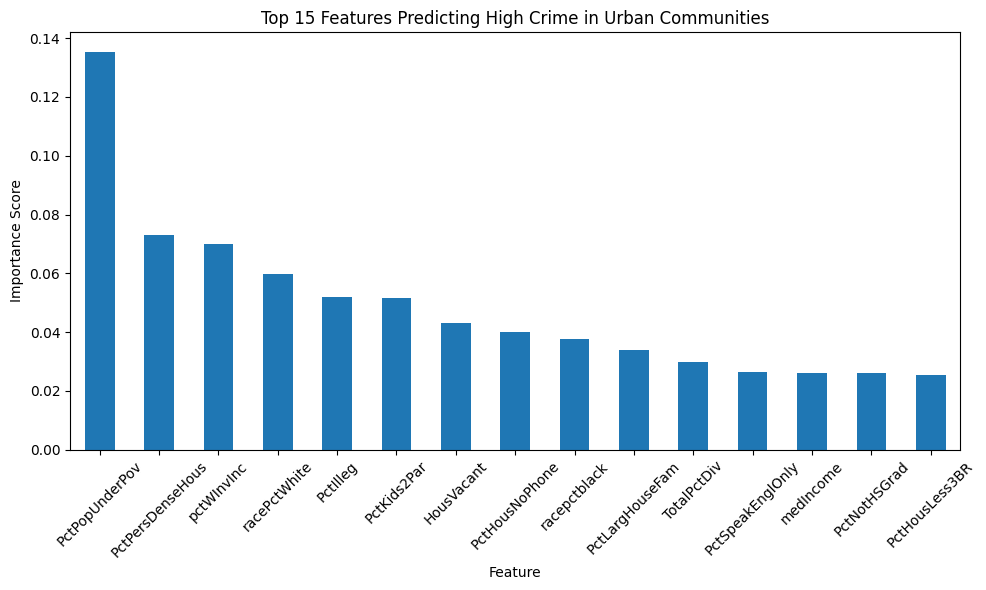

In [99]:
#Feature Importance Plot: shows which urban variables most influence crime predictin in Random forest
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_importance.head(15).plot(kind='bar')

plt.title("Top 15 Features Predicting High Crime in Urban Communities")
plt.ylabel("Importance Score")
plt.xlabel("Feature")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

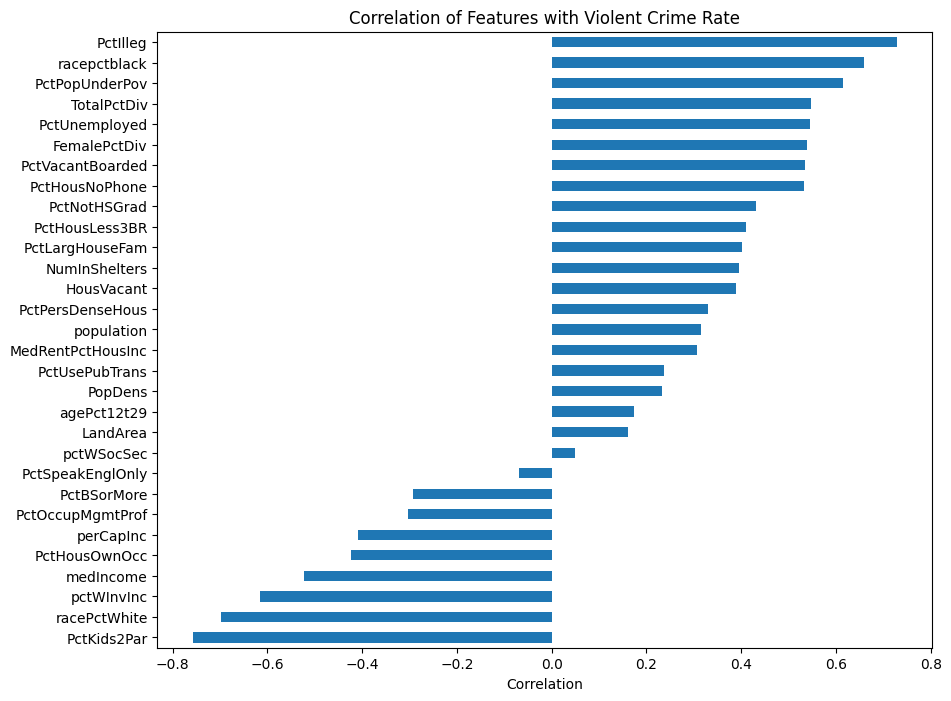

In [100]:
#Correlation Bar Chart with Crime
crime_corr = clean_df[features + ['ViolentCrimesPerPop']].corr()['ViolentCrimesPerPop']

crime_corr = crime_corr.drop('ViolentCrimesPerPop').sort_values()

plt.figure(figsize=(10,8))

crime_corr.plot(kind='barh')

plt.title("Correlation of Features with Violent Crime Rate")
plt.xlabel("Correlation")

plt.show()

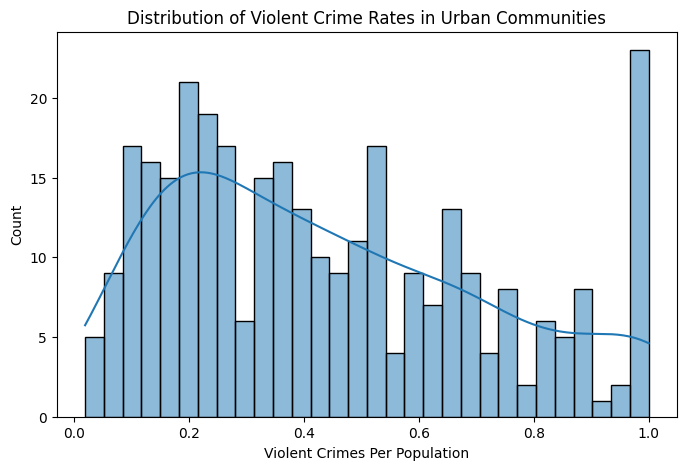

In [101]:
#Crime rate Dist. 
plt.figure(figsize=(8,5))

sns.histplot(
    clean_df['ViolentCrimesPerPop'],
    bins=30,
    kde=True
)

plt.title("Distribution of Violent Crime Rates in Urban Communities")
plt.xlabel("Violent Crimes Per Population")

plt.show()

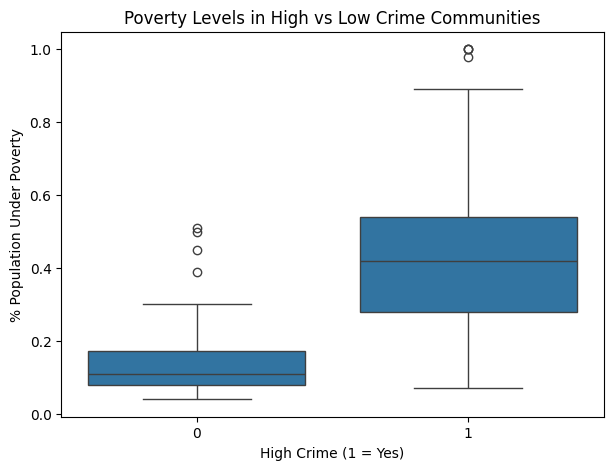

In [102]:
#Key Predictors vs Crime
plt.figure(figsize=(7,5))

sns.boxplot(
    x='HighCrime',
    y='PctPopUnderPov',
    data=clean_df
)

plt.title("Poverty Levels in High vs Low Crime Communities")
plt.xlabel("High Crime (1 = Yes)")
plt.ylabel("% Population Under Poverty")

plt.show()

In [104]:
#Lasso 

epsilon = 0.0001

clean_df['ViolentCrimesBeta'] = clean_df['ViolentCrimesPerPop'].clip(epsilon, 1-epsilon)
dirty_df['ViolentCrimesBeta'] = dirty_df['ViolentCrimesPerPop'].clip(epsilon, 1-epsilon)

threshold = 0.1

clean_df['HighCrime'] = (clean_df['ViolentCrimesPerPop'] > threshold).astype(int)

X = clean_df[features]

y_reg = clean_df['ViolentCrimesPerPop']
y_beta = clean_df['ViolentCrimesBeta']
y_class = clean_df['HighCrime']

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg,
    test_size=0.2,
    random_state=42
)

_, _, y_train_class, y_test_class = train_test_split(
    X, y_class,
    test_size=0.2,
    random_state=42
)

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01))
])

lasso_pipeline.fit(X_train, y_train_reg)

y_pred_lasso = lasso_pipeline.predict(X_test)

mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)

print("Lasso MSE:", mse_lasso)

y_pred_class = (y_pred_lasso > threshold).astype(int)

accuracy_lasso = accuracy_score(y_test_class, y_pred_class)
precision_lasso = precision_score(y_test_class, y_pred_class)
recall_lasso = recall_score(y_test_class, y_pred_class)
f1_lasso = f1_score(y_test_class, y_pred_class)

print("Accuracy:", accuracy_lasso)
print("Precision:", precision_lasso)
print("Recall:", recall_lasso)
print("F1 Score:", f1_lasso)

lasso_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01))
])

cv_scores = cross_val_score(
    lasso_cv,
    X,
    y_reg,
    cv=10,
    scoring='neg_mean_squared_error'
)

print("10-Fold CV MSE:", -cv_scores.mean())



Lasso MSE: 0.025262597525979244
Accuracy: 0.96875
Precision: 0.9836065573770492
Recall: 0.9836065573770492
F1 Score: 0.9836065573770492
10-Fold CV MSE: 0.028350174166259234


/var/folders/gq/vx40gmgs7r3ctcswx6p9jk200000gn/T/ipykernel_1076/333396387.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dirty_df['ViolentCrimesBeta'] = dirty_df['ViolentCrimesPerPop'].clip(epsilon, 1-epsilon)


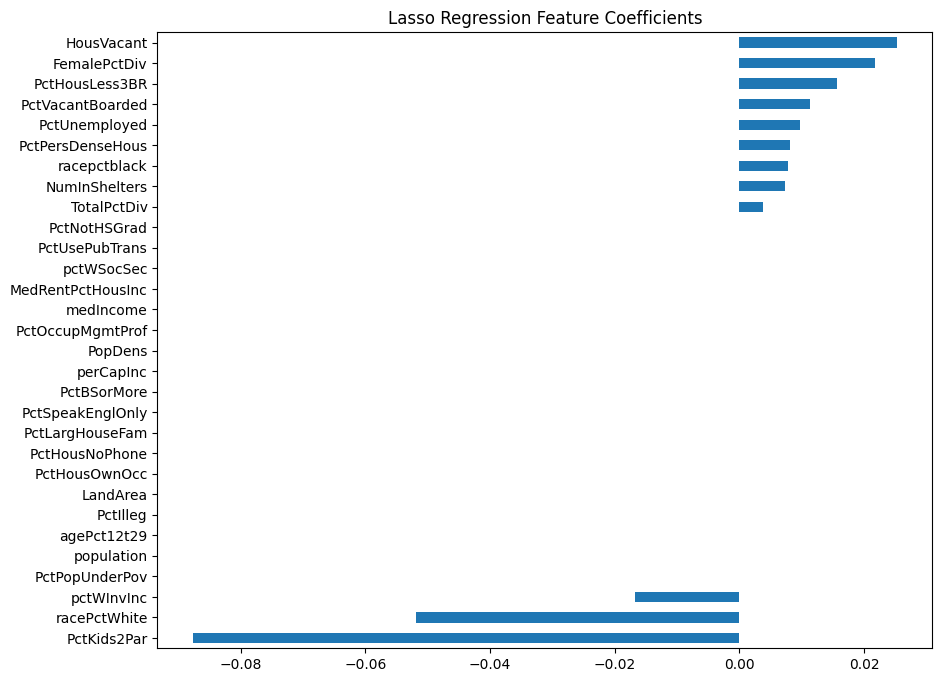

In [105]:
lasso_model = lasso_pipeline.named_steps['lasso']

coefficients = pd.Series(
    lasso_model.coef_,
    index=features
)

coefficients = coefficients.sort_values()

plt.figure(figsize=(10,8))

coefficients.plot(kind='barh')

plt.title("Lasso Regression Feature Coefficients")

plt.show()



In [106]:
lasso_importance = pd.Series(
    lasso_model.coef_,
    index=features
)

top5_lasso = lasso_importance.abs().sort_values(ascending=False).head(5)

print("Top 5 Lasso Features:")
print(top5_lasso)

Top 5 Lasso Features:
PctKids2Par     0.087683
racePctWhite    0.051899
HousVacant      0.025305
FemalePctDiv    0.021784
pctWInvInc      0.016763
dtype: float64


In [107]:
#Beta Regression

X_beta = sm.add_constant(X)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_beta,
    y_beta,
    test_size=0.2,
    random_state=42
    
)

beta_model = BetaModel(y_train_b, X_train_b)

beta_results = beta_model.fit()

print(beta_results.summary())

y_pred_beta = beta_results.predict(X_test_b)

mse_beta = mean_squared_error(y_test_b, y_pred_beta)

print("Beta Regression MSE:", mse_beta)

y_pred_class_beta = (y_pred_beta > threshold).astype(int)

accuracy_beta = accuracy_score(y_test_class, y_pred_class_beta)
precision_beta = precision_score(y_test_class, y_pred_class_beta)
recall_beta = recall_score(y_test_class, y_pred_class_beta)
f1_beta = f1_score(y_test_class, y_pred_class_beta)

print("Accuracy:", accuracy_beta)
print("Precision:", precision_beta)
print("Recall:", recall_beta)
print("F1 Score:", f1_beta)

beta_importance = pd.Series(
    beta_results.params[1:], 
    index=features
)

top5_beta = beta_importance.abs().sort_values(ascending=False).head(5)

print("Top 5 Beta Regression Features:")
print(top5_beta)

                              BetaModel Results                               
Dep. Variable:      ViolentCrimesBeta   Log-Likelihood:                 162.18
Model:                      BetaModel   AIC:                            -260.4
Method:            Maximum Likelihood   BIC:                            -147.3
Date:                Tue, 10 Mar 2026                                         
Time:                        23:29:51                                         
No. Observations:                 253                                         
Df Residuals:                     221                                         
Df Model:                          30                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.7846      2.408      0.741      0.459      -2.934       6.504
PctPopUnderPov       -1.0143   

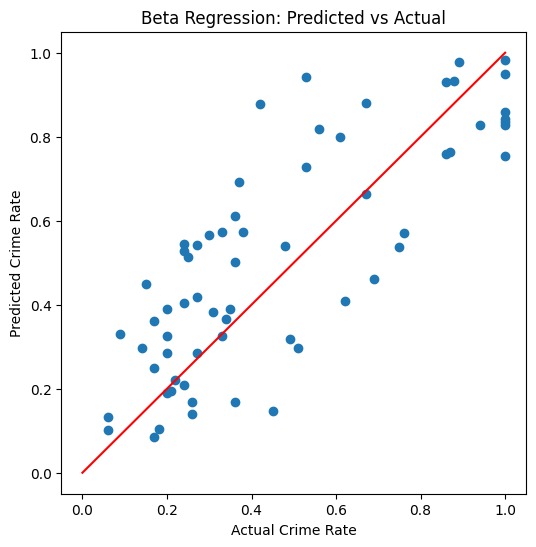

In [108]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_b, y_pred_beta)

plt.xlabel("Actual Crime Rate")
plt.ylabel("Predicted Crime Rate")

plt.title("Beta Regression: Predicted vs Actual")

plt.plot([0,1], [0,1], color='red')

plt.show()

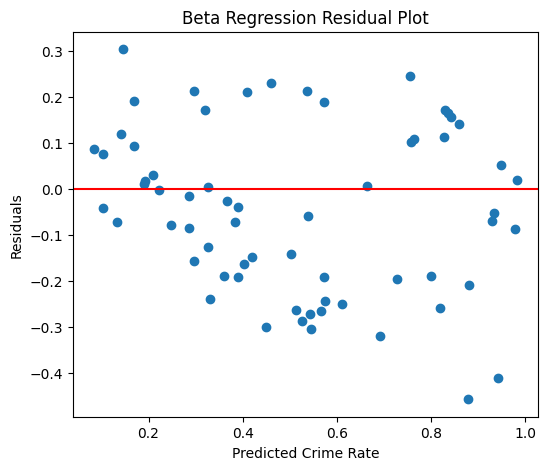

In [109]:
residuals = y_test_b - y_pred_beta

plt.figure(figsize=(6,5))

plt.scatter(y_pred_beta, residuals)

plt.axhline(0, color='red')

plt.xlabel("Predicted Crime Rate")
plt.ylabel("Residuals")

plt.title("Beta Regression Residual Plot")

plt.show()

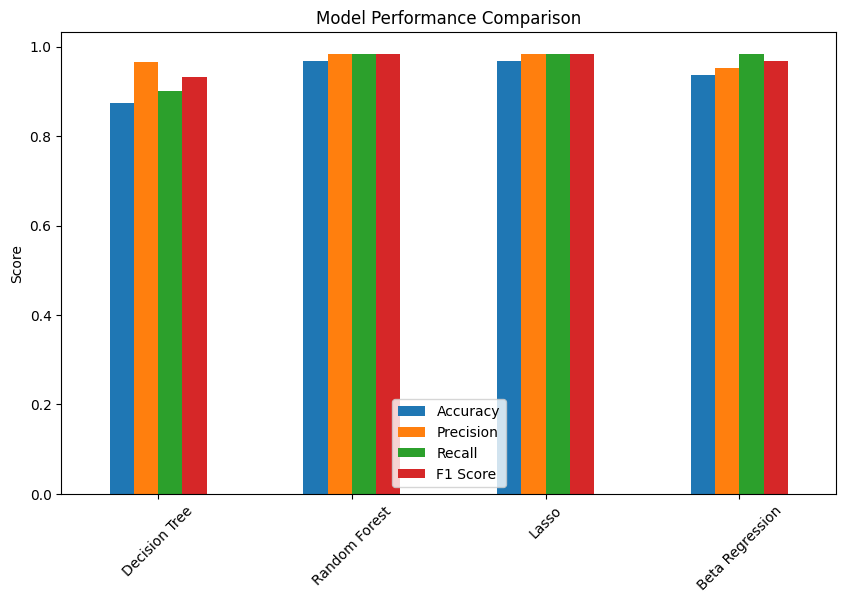

In [110]:
results = pd.DataFrame({
    'Accuracy': [accuracy_dt, accuracy_rf, accuracy_lasso, accuracy_beta],
    'Precision': [precision_dt, precision_rf, precision_lasso, precision_beta],
    'Recall': [recall_dt, recall_rf, recall_lasso, recall_beta],
    'F1 Score': [f1_dt, f1_rf, f1_lasso, f1_beta]
},
index=[
    'Decision Tree',
    'Random Forest',
    'Lasso',
    'Beta Regression'
])

results.plot(kind='bar', figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.show()

In [ ]:

X_sm = sm.add_constant(X)

linear_model = sm.OLS(y_reg, X_sm).fit()

print("Linear Regression AIC:", linear_model.aic)
print("Linear Regression BIC:", linear_model.bic)

poisson_model = sm.GLM(
    y_reg,
    X_sm,
    family=sm.families.Poisson()
).fit()

print("Poisson AIC:", poisson_model.aic)
print("Poisson BIC:", poisson_model.bic_llf)

loglinear_model = sm.GLM(
    y_reg,
    X_sm,
    family=sm.families.Poisson(link=sm.families.links.log())
).fit()

print("Log-linear AIC:", loglinear_model.aic)
print("Log-linear BIC:", loglinear_model.bic)



beta_model = BetaModel(y_beta, X_sm).fit()

print("Beta Regression AIC:", beta_model.aic)
print("Beta Regression BIC:", beta_model.bic)


lasso_bic = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoLarsIC(criterion='bic'))
])

lasso_bic.fit(X, y_reg)

print("Optimal alpha using BIC:", lasso_bic.named_steps['lasso'].alpha_)

cv_scores_rf = cross_val_score(
    rf_model,
    X,
    y_class,
    cv=10,
    scoring='accuracy'
)

print("Random Forest CV Accuracy:", cv_scores_rf.mean())

Linear Regression AIC: -227.94174619718774
Linear Regression BIC: -111.41579120699205
Poisson AIC: 478.25869182120766
Poisson BIC: 594.7846468114034
Log-linear AIC: 478.25869182120766
Log-linear BIC: -1630.1461965081594
Beta Regression AIC: -348.13016023586476
Beta Regression BIC: -227.8453034717918
Optimal alpha using BIC: 0.017601680989920696


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


Random Forest CV Accuracy: 0.9213709677419356


In [112]:
top_features = pd.DataFrame({
    "Linear": top5_linear.index,
    "DecisionTree": top5_dt.index,
    "RandomForest": top5_rf.index,
    "Lasso": top5_lasso.index,
    "Beta": top5_beta.index
})

print(top_features)

          Linear    DecisionTree      RandomForest         Lasso          Beta
0     pctWInvInc      pctWInvInc    PctPopUnderPov   PctKids2Par    pctWInvInc
1   PctNotHSGrad    racePctWhite  PctPersDenseHous  racePctWhite   PctBSorMore
2    PctBSorMore  PctPopUnderPov        pctWInvInc    HousVacant   PctKids2Par
3    PctKids2Par      HousVacant      racePctWhite  FemalePctDiv  PctNotHSGrad
4  PctHousOwnOcc   PctHousOwnOcc          PctIlleg    pctWInvInc    population


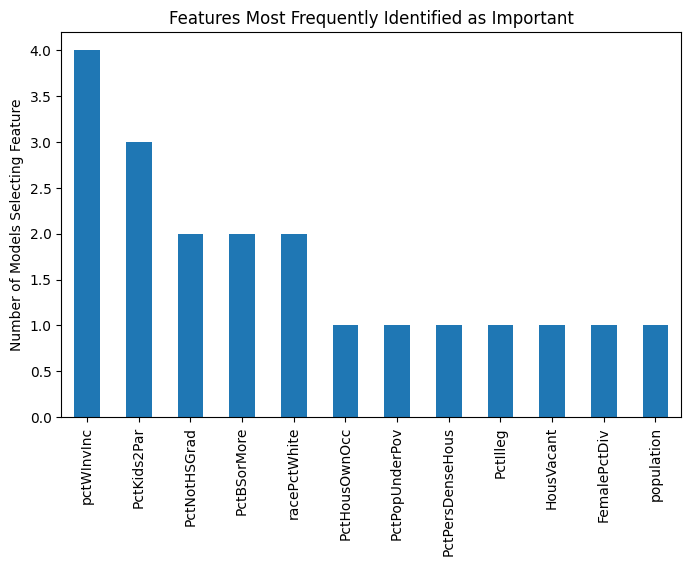

In [113]:
feature_counts = pd.Series(
    list(top5_linear.index) +
    list(top5_rf.index) +
    list(top5_lasso.index) +
    list(top5_beta.index)
).value_counts()

plt.figure(figsize=(8,5))

feature_counts.plot(kind="bar")

plt.title("Features Most Frequently Identified as Important")

plt.ylabel("Number of Models Selecting Feature")

plt.show()